In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_excel("../data/raw/credit_default.xls",header=1)

target = "default payment next month"

display(df.head(5))

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
0,1,20000,2,2,1,24,2,2,-1,-1,...,0,0,0,0,689,0,0,0,0,1
1,2,120000,2,2,2,26,-1,2,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,3,90000,2,2,2,34,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,4,50000,2,2,1,37,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,5,50000,1,2,1,57,-1,0,-1,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0


In [4]:
pd.crosstab(df["default payment next month"],df["SEX"],normalize="index")*100

SEX,1,2
default payment next month,,
0,38.585003,61.414997
1,43.294153,56.705847


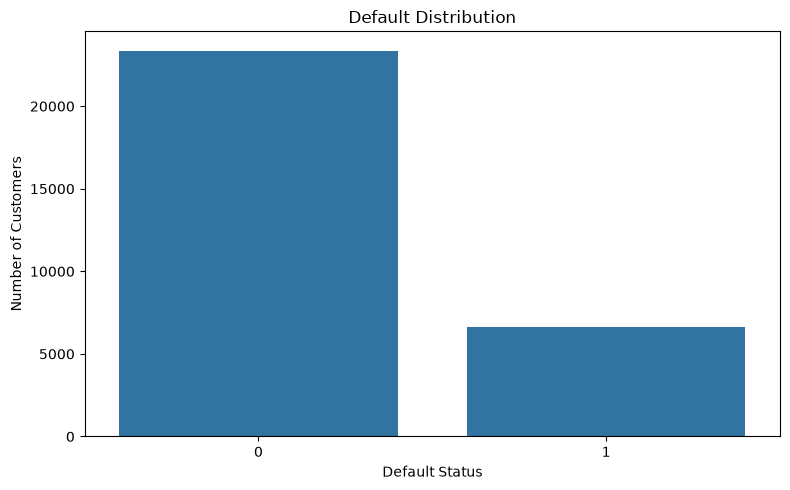

In [5]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x=target)
plt.xlabel("Default Status")
plt.ylabel("Number of Customers")
plt.title("Default Distribution")
plt.tight_layout()
plt.savefig("../reports/figures/target_distribution.png", dpi=300)
plt.show()

In [6]:
default_rate = df[target].value_counts(normalize=True) * 100

print(default_rate)

default payment next month
0    77.88
1    22.12
Name: proportion, dtype: float64


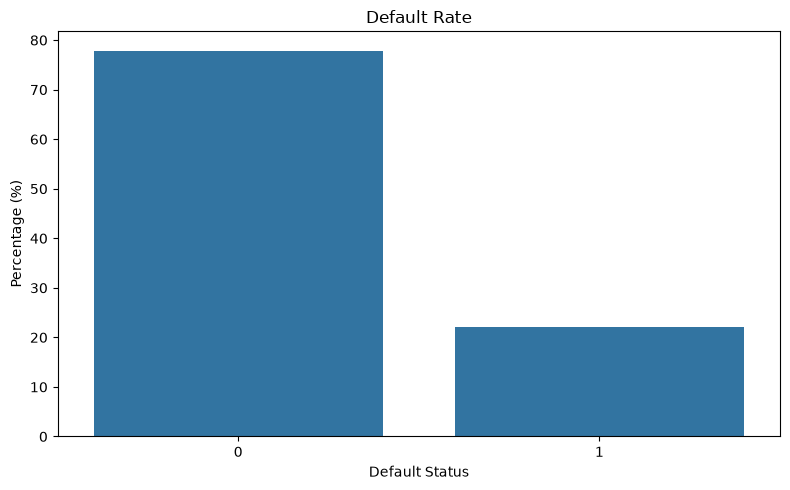

In [7]:
plt.figure(figsize=(8, 5))
sns.barplot(x=default_rate.index, y=default_rate.values)
plt.xlabel("Default Status")
plt.ylabel("Percentage (%)")
plt.title("Default Rate")
plt.tight_layout()
plt.savefig("../reports/figures/default_rate.png", dpi=300)
plt.show()

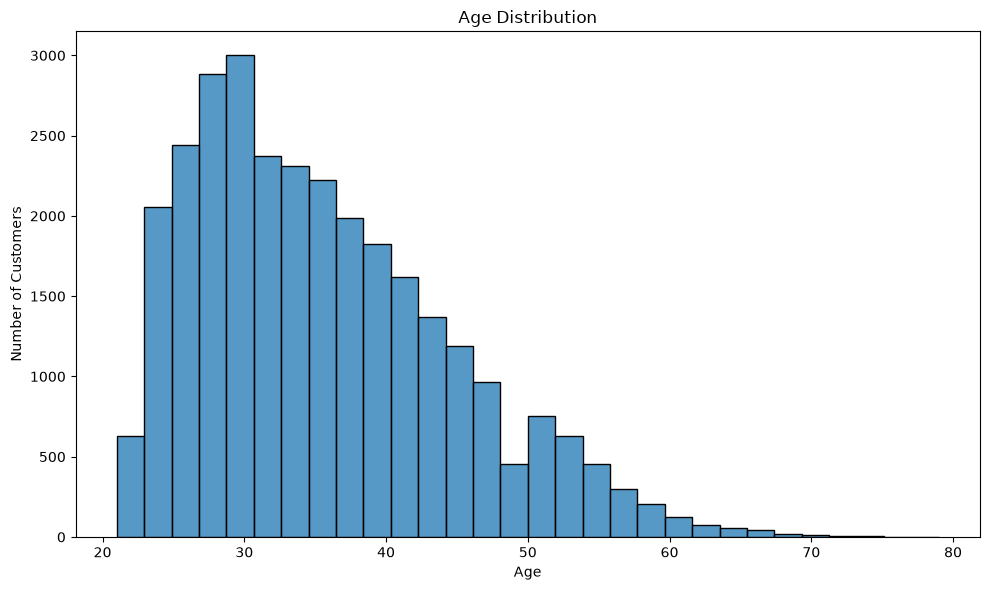

In [8]:
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x="AGE", bins=30)
plt.xlabel("Age")
plt.ylabel("Number of Customers")
plt.title("Age Distribution")
plt.tight_layout()
plt.savefig("../reports/figures/age_distribution.png", dpi=300)
plt.show()

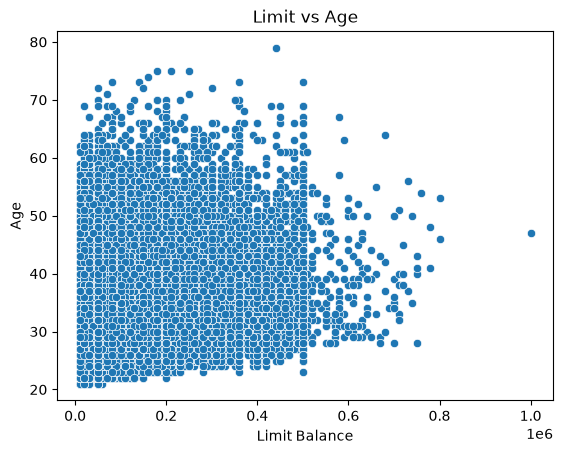

In [9]:
sns.scatterplot(
    data=df,
    x="LIMIT_BAL",
    y="AGE"
)

plt.xlabel("Limit Balance")
plt.ylabel("Age")
plt.title("Limit vs Age")
plt.show()

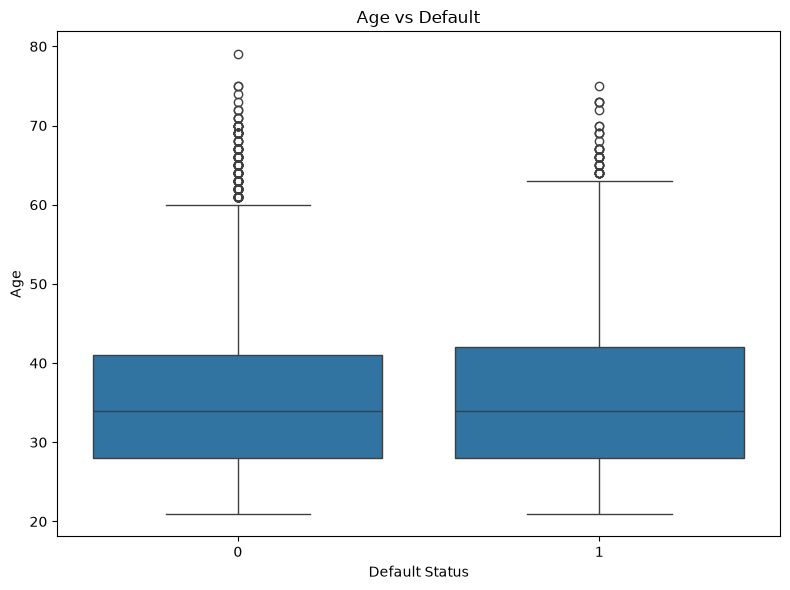

In [10]:
plt.figure(figsize=(8, 6))
sns.boxplot(data=df, x=target, y="AGE")
plt.xlabel("Default Status")
plt.ylabel("Age")
plt.title("Age vs Default")
plt.tight_layout()
plt.savefig("../reports/figures/age_vs_default.png", dpi=300)
plt.show()

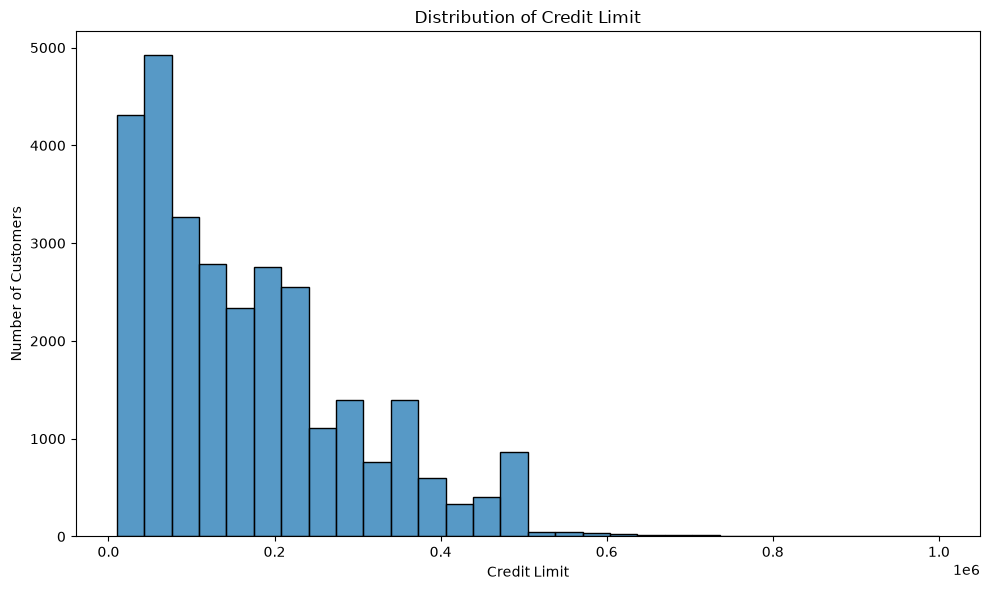

In [11]:
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x="LIMIT_BAL", bins=30)
plt.xlabel("Credit Limit")
plt.ylabel("Number of Customers")
plt.title("Distribution of Credit Limit")
plt.tight_layout()
plt.savefig("../reports/figures/credit_limit_distribution.png", dpi=300)
plt.show()

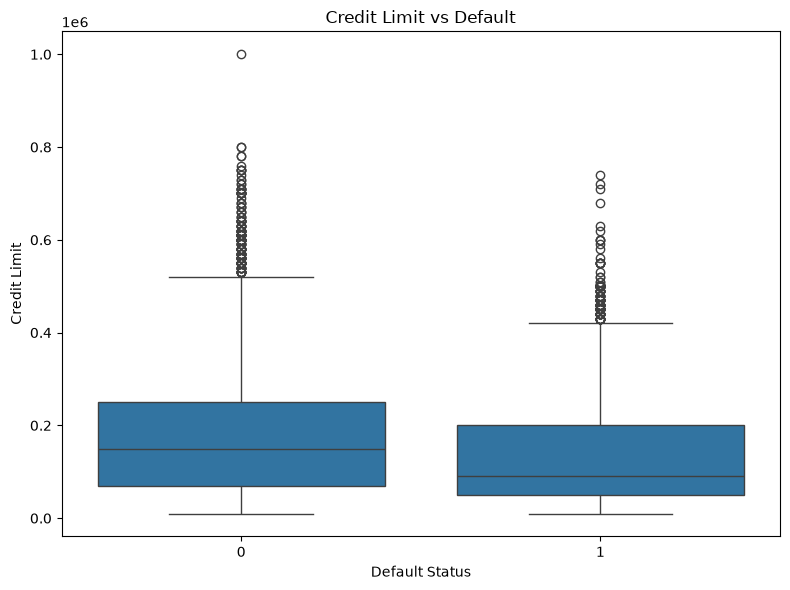

In [12]:
plt.figure(figsize=(8, 6))
sns.boxplot(data=df, x=target, y="LIMIT_BAL")
plt.xlabel("Default Status")
plt.ylabel("Credit Limit")
plt.title("Credit Limit vs Default")
plt.tight_layout()
plt.savefig("../reports/figures/credit_limit_vs_default.png", dpi=300)
plt.show()

default payment next month           0          1
EDUCATION                                        
0                           100.000000   0.000000
1                            80.765234  19.234766
2                            76.265146  23.734854
3                            74.842384  25.157616
4                            94.308943   5.691057
5                            93.571429   6.428571
6                            84.313725  15.686275


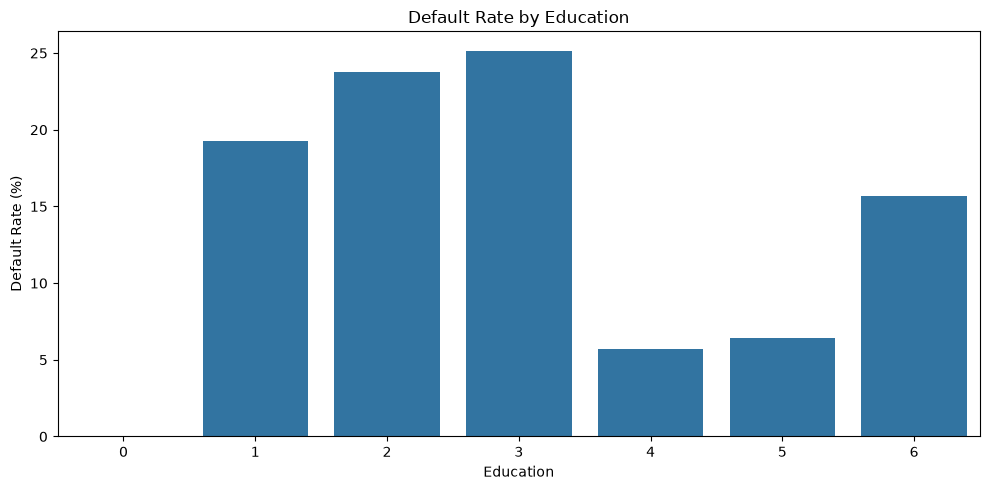

In [13]:
education_default = pd.crosstab(
    df["EDUCATION"],
    df[target],
    normalize="index"
) * 100

print(education_default)

plt.figure(figsize=(10, 5))

sns.barplot(
    x=education_default.index,
    y=education_default[1]
)

plt.xlabel("Education")
plt.ylabel("Default Rate (%)")
plt.title("Default Rate by Education")

plt.tight_layout()

plt.savefig(
    "../reports/figures/education_vs_default.png",
    dpi=300
)

plt.show()

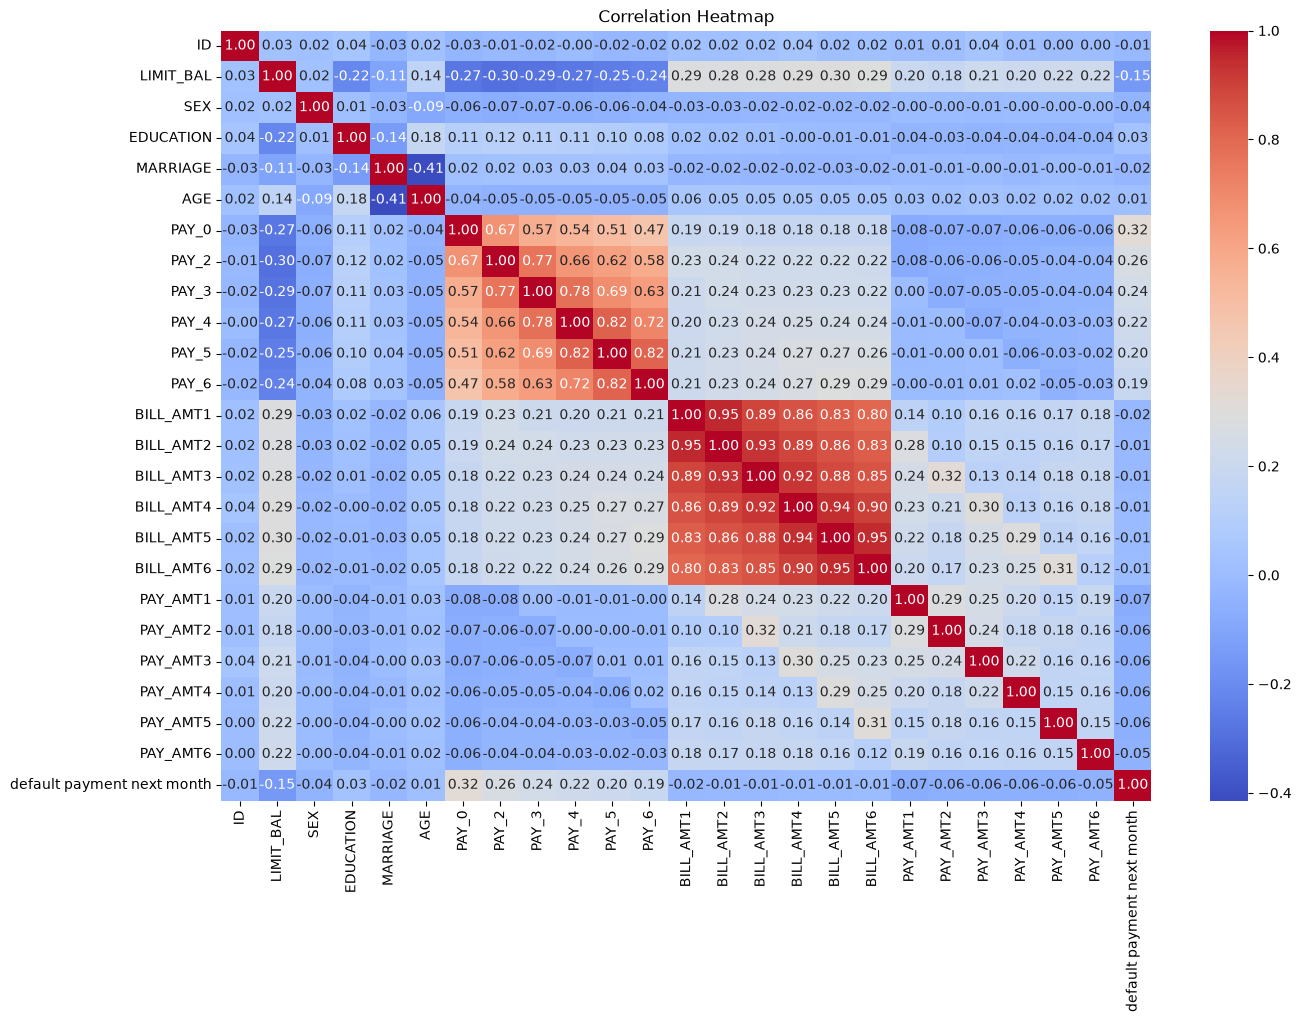

In [14]:
numeric_df = df.select_dtypes(include="number")

correlation = numeric_df.corr()

plt.figure(figsize=(15, 10))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.show()

In [15]:
pd.crosstab(df["default payment next month"],df["EDUCATION"],normalize="index")*100

EDUCATION,0,1,2,3,4,5,6
default payment next month,,,,,,,
0,0.059921,36.590481,45.796953,15.750728,0.496490,1.121383,0.184044
1,0.000000,30.681133,50.180832,18.640747,0.105485,0.271248,0.120555


In [16]:
pd.crosstab(df["default payment next month"],df["MARRIAGE"],normalize="index")*100

MARRIAGE,0,1,2,3
default payment next month,,,,
0,0.209724,44.739771,54.027564,1.022941
1,0.075347,48.312236,50.346594,1.265823


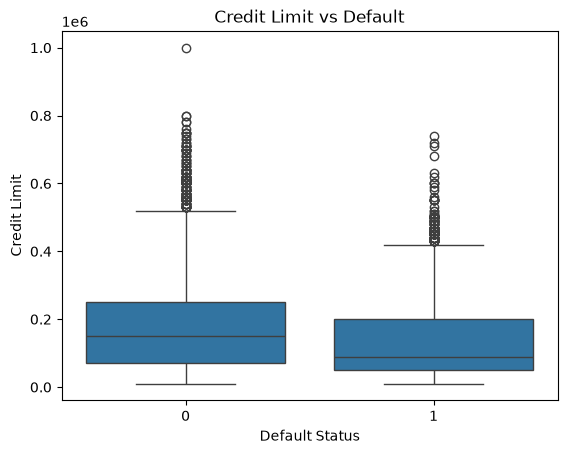

In [17]:
sns.boxplot(
    x="default payment next month",
    y="LIMIT_BAL",
    data=df
)

plt.xlabel("Default Status")
plt.ylabel("Credit Limit")
plt.title("Credit Limit vs Default")
plt.show()

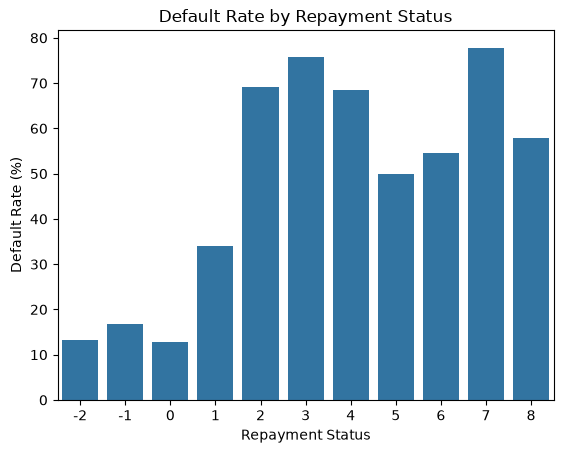

In [18]:
default_rate = df.groupby("PAY_0")["default payment next month"].mean() * 100

sns.barplot(
    x=default_rate.index,
    y=default_rate.values
)

plt.xlabel("Repayment Status")
plt.ylabel("Default Rate (%)")
plt.title("Default Rate by Repayment Status")
plt.show()

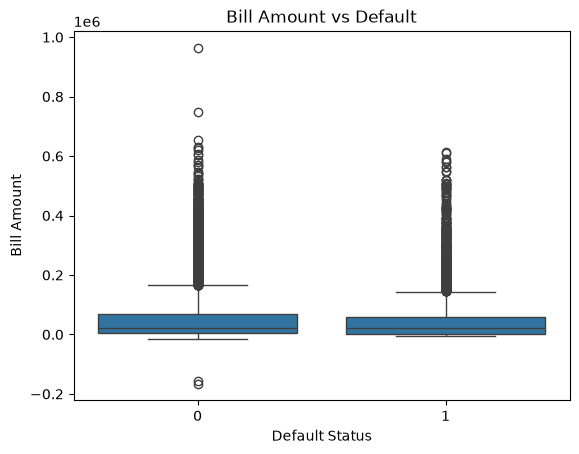

In [19]:
sns.boxplot(
    x="default payment next month",
    y="BILL_AMT1",
    data=df
)

plt.xlabel("Default Status")
plt.ylabel("Bill Amount")
plt.title("Bill Amount vs Default")
plt.show()

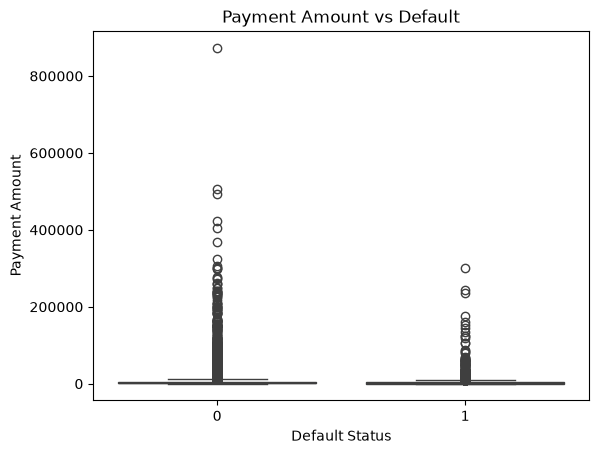

In [20]:
sns.boxplot(
    x="default payment next month",
    y="PAY_AMT1",
    data=df
)

plt.xlabel("Default Status")
plt.ylabel("Payment Amount")
plt.title("Payment Amount vs Default")
plt.show()

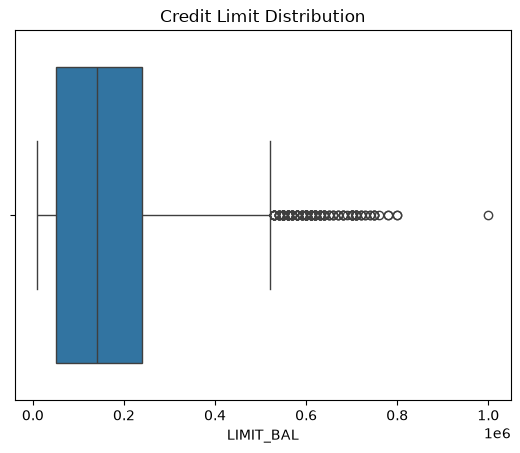

In [21]:
sns.boxplot(x=df["LIMIT_BAL"])

plt.title("Credit Limit Distribution")
plt.show()

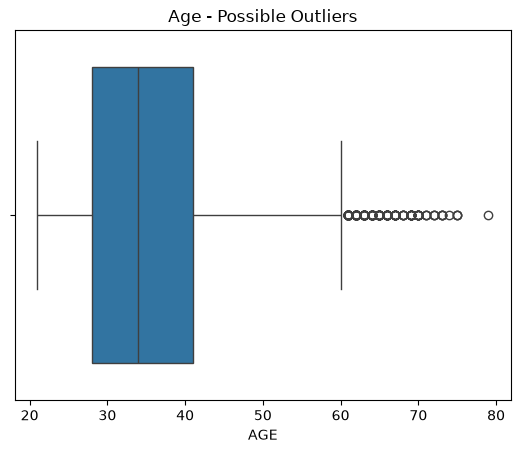

In [22]:
sns.boxplot(x=df["AGE"])

plt.title("Age - Possible Outliers")
plt.show()

In [23]:
pd.crosstab(df["SEX"], df["default payment next month"])

default payment next month,0,1
SEX,,
1,9015,2873
2,14349,3763


In [24]:
pd.crosstab(df["EDUCATION"], df["default payment next month"])

default payment next month,0,1
EDUCATION,,
0,14,0
1,8549,2036
2,10700,3330
3,3680,1237
4,116,7
5,262,18
6,43,8


In [25]:
pd.crosstab(df["MARRIAGE"], df["default payment next month"])

default payment next month,0,1
MARRIAGE,,
0,49,5
1,10453,3206
2,12623,3341
3,239,84


In [26]:
pd.crosstab(
    df["EDUCATION"],
    df["default payment next month"],
    normalize="index"
) * 100

default payment next month,0,1
EDUCATION,,
0,100.000000,0.000000
1,80.765234,19.234766
2,76.265146,23.734854
3,74.842384,25.157616
4,94.308943,5.691057
5,93.571429,6.428571
6,84.313725,15.686275


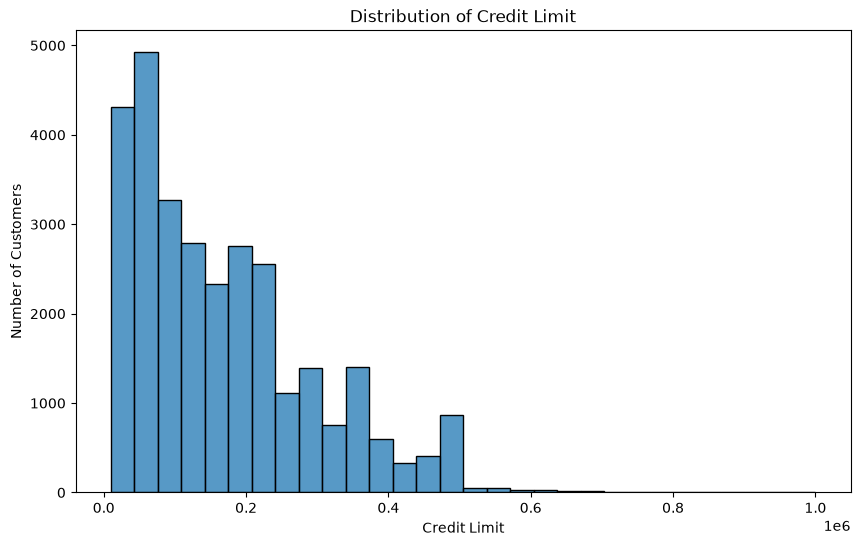

In [27]:
plt.figure(figsize=(10, 6))

sns.histplot(
    data=df,
    x="LIMIT_BAL",
    bins=30
)

plt.xlabel("Credit Limit")
plt.ylabel("Number of Customers")
plt.title("Distribution of Credit Limit")
plt.show()

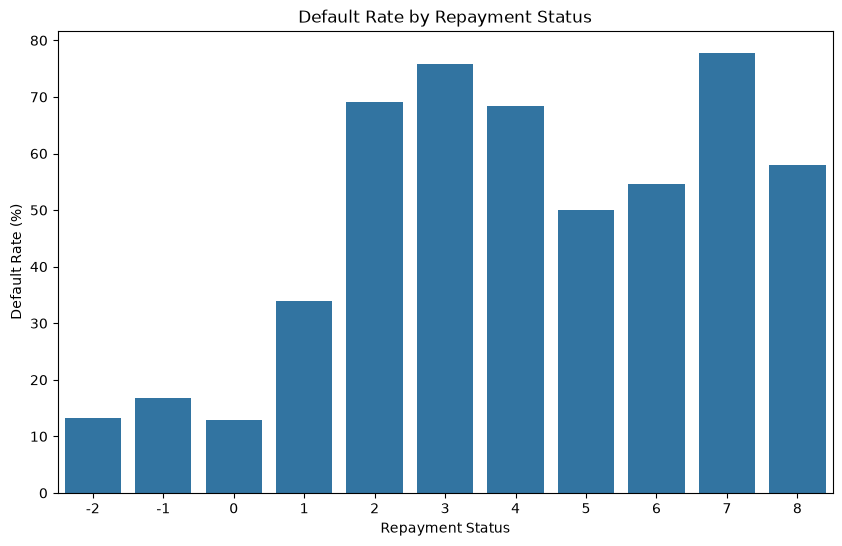

In [28]:


default_rate = (
    df.groupby("PAY_0")["default payment next month"]
      .mean() * 100
)

plt.figure(figsize=(10, 6))

sns.barplot(
    x=default_rate.index,
    y=default_rate.values
)

plt.xlabel("Repayment Status")
plt.ylabel("Default Rate (%)")
plt.title("Default Rate by Repayment Status")

plt.show()

default payment next month          0          1
SEX                                             
1                           75.832773  24.167227
2                           79.223719  20.776281


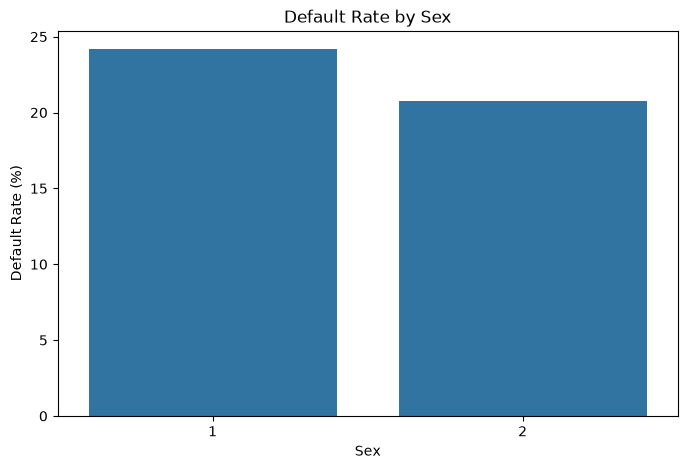

In [29]:
sex_default = pd.crosstab(
    df["SEX"],
    df[target],
    normalize="index"
) * 100

print(sex_default)

plt.figure(figsize=(8, 5))
sns.barplot(
    x=sex_default.index,
    y=sex_default[1]
)
plt.xlabel("Sex")
plt.ylabel("Default Rate (%)")
plt.title("Default Rate by Sex")
plt.show()

default payment next month          0          1
MARRIAGE                                        
0                           90.740741   9.259259
1                           76.528296  23.471704
2                           79.071661  20.928339
3                           73.993808  26.006192


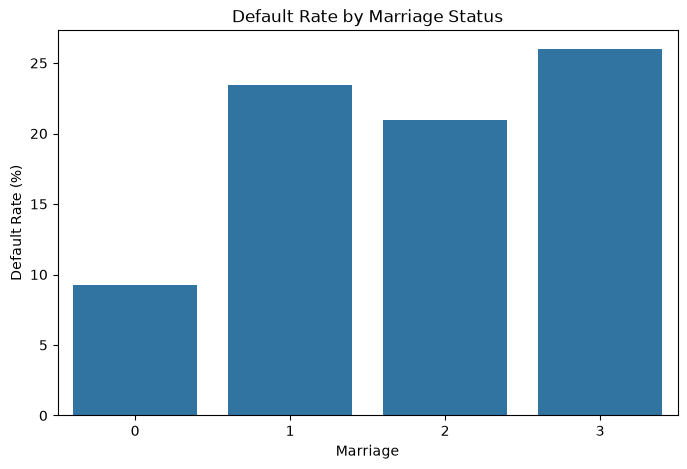

In [30]:
marriage_default = pd.crosstab(
    df["MARRIAGE"],
    df[target],
    normalize="index"
) * 100

print(marriage_default)

plt.figure(figsize=(8, 5))
sns.barplot(
    x=marriage_default.index,
    y=marriage_default[1]
)
plt.xlabel("Marriage")
plt.ylabel("Default Rate (%)")
plt.title("Default Rate by Marriage Status")
plt.show()

default payment next month           0          1
EDUCATION                                        
0                           100.000000   0.000000
1                            80.765234  19.234766
2                            76.265146  23.734854
3                            74.842384  25.157616
4                            94.308943   5.691057
5                            93.571429   6.428571
6                            84.313725  15.686275


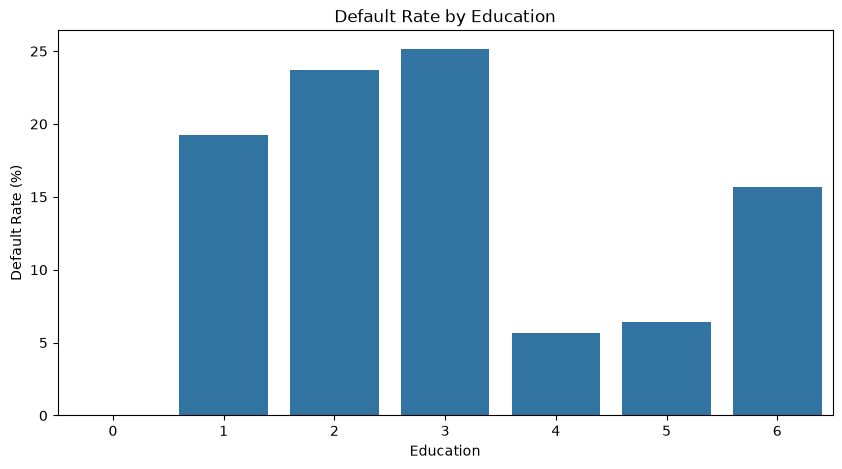

In [31]:
education_default = pd.crosstab(
    df["EDUCATION"],
    df[target],
    normalize="index"
) * 100

print(education_default)

plt.figure(figsize=(10, 5))
sns.barplot(
    x=education_default.index,
    y=education_default[1]
)
plt.xlabel("Education")
plt.ylabel("Default Rate (%)")
plt.title("Default Rate by Education")
plt.show()

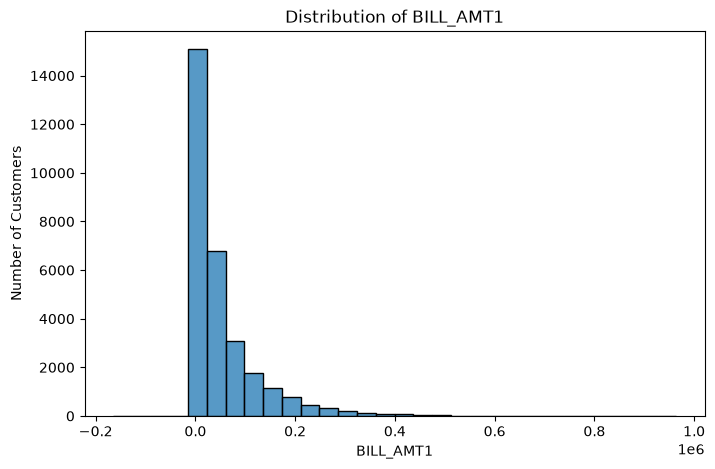

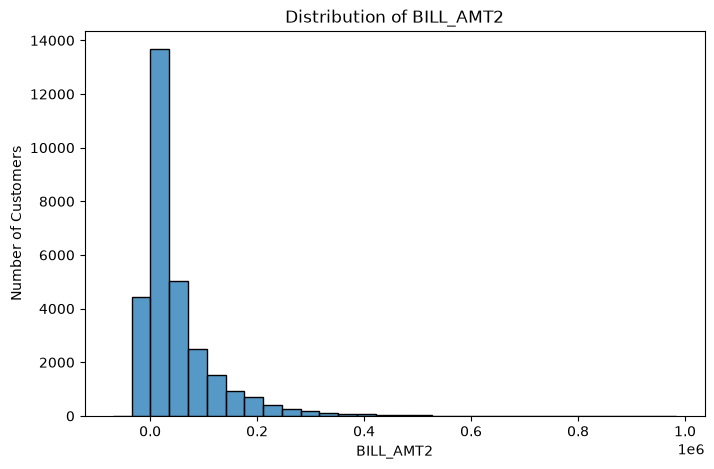

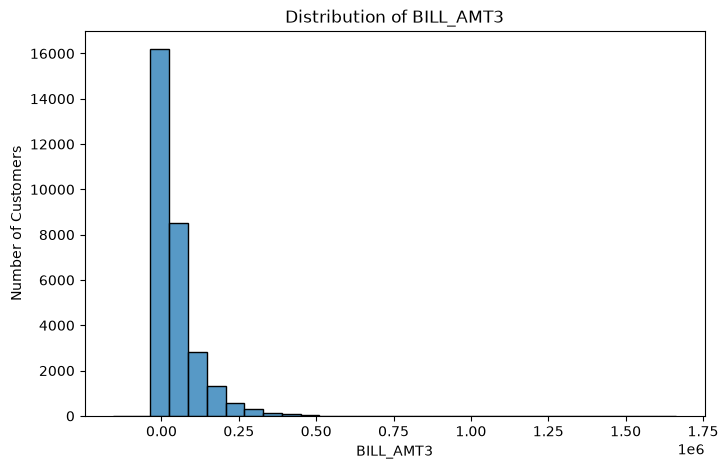

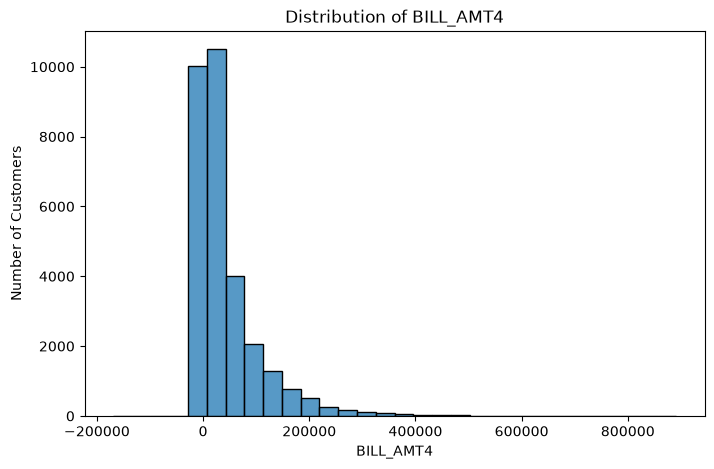

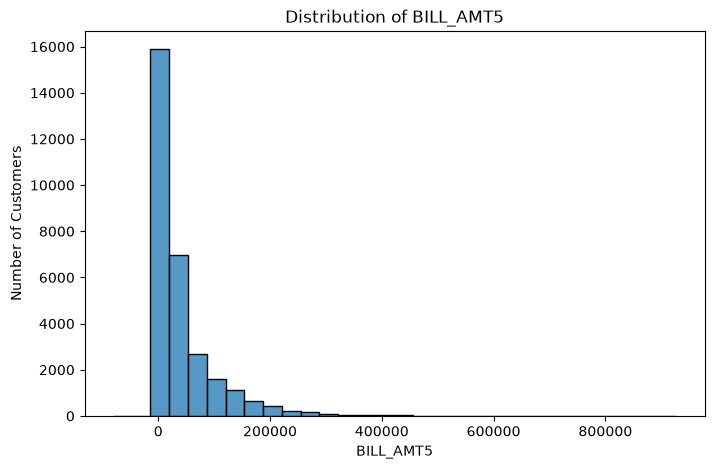

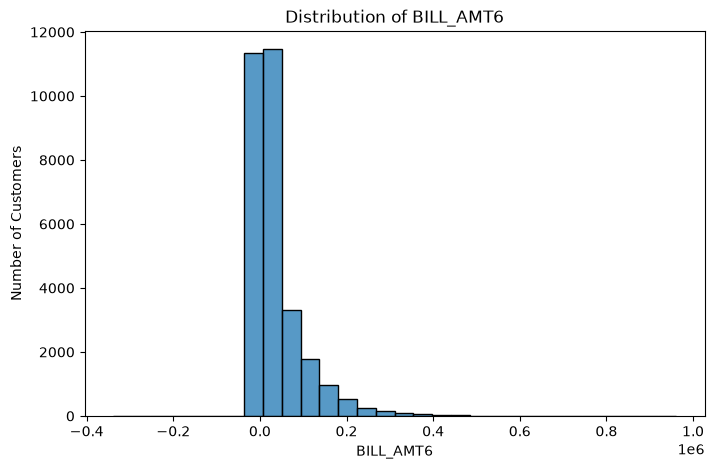

In [32]:
bill_cols = [
    "BILL_AMT1",
    "BILL_AMT2",
    "BILL_AMT3",
    "BILL_AMT4",
    "BILL_AMT5",
    "BILL_AMT6"
]

for col in bill_cols:
    plt.figure(figsize=(8, 5))
    sns.histplot(data=df, x=col, bins=30)
    plt.xlabel(col)
    plt.ylabel("Number of Customers")
    plt.title(f"Distribution of {col}")
    plt.show()

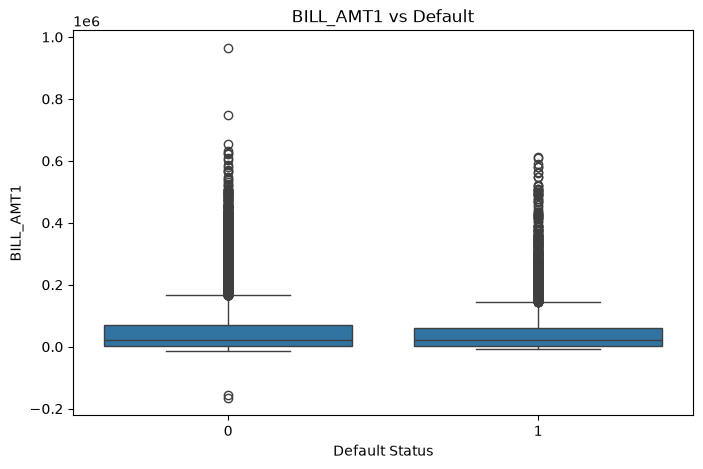

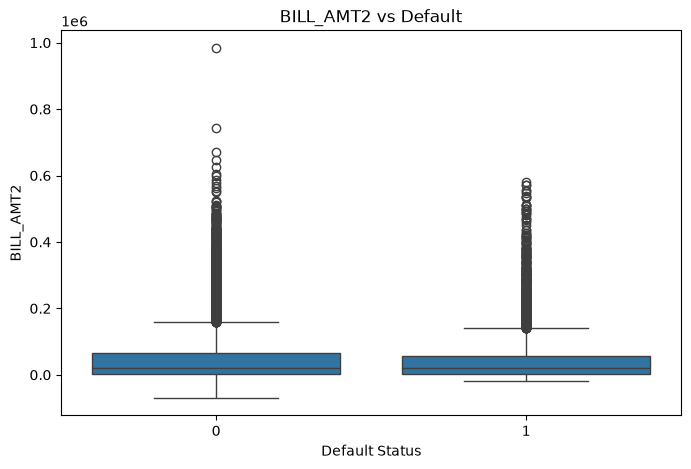

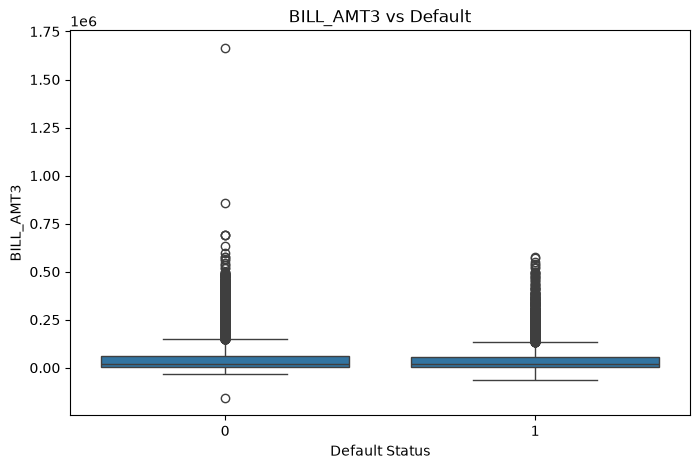

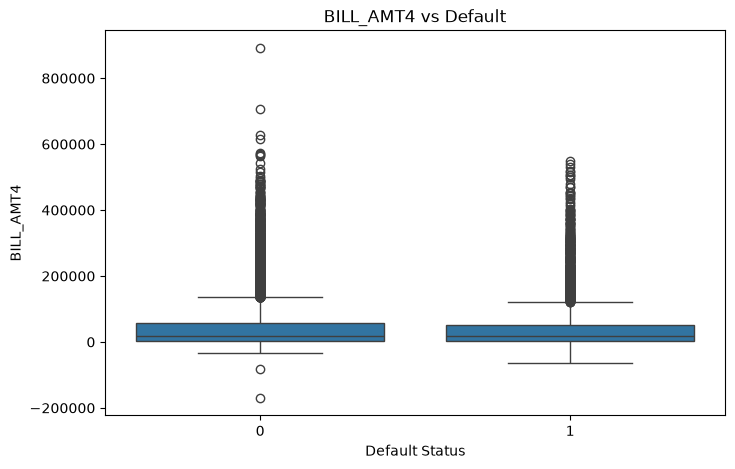

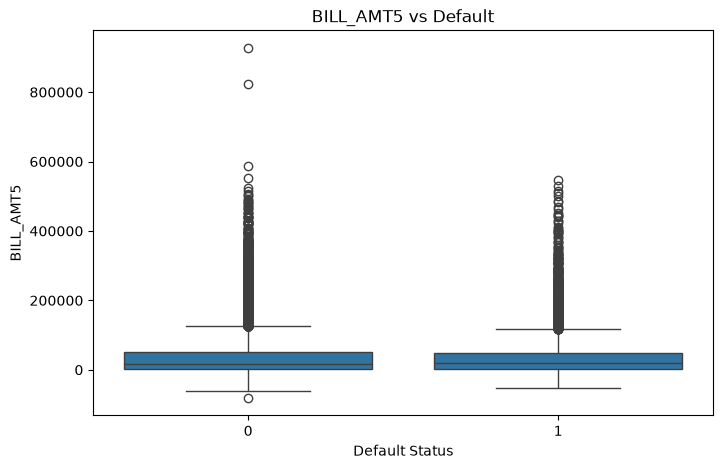

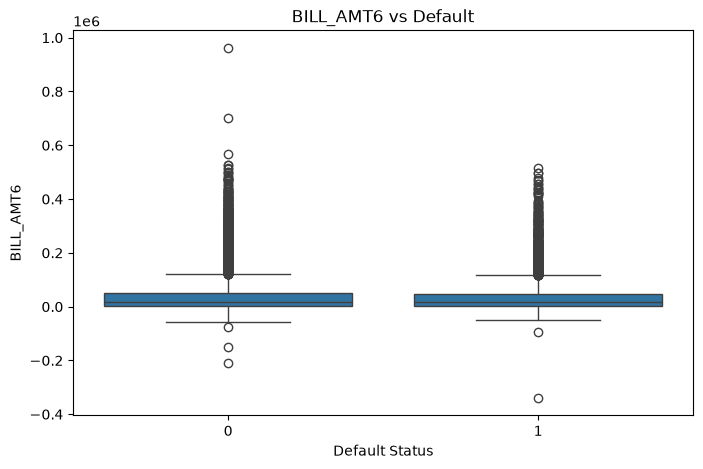

In [33]:
for col in bill_cols:
    plt.figure(figsize=(8, 5))
    sns.boxplot(data=df, x=target, y=col)
    plt.xlabel("Default Status")
    plt.ylabel(col)
    plt.title(f"{col} vs Default")
    plt.show()


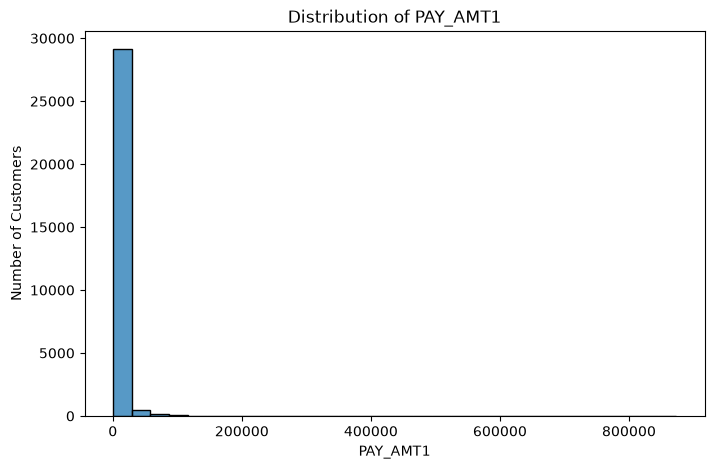

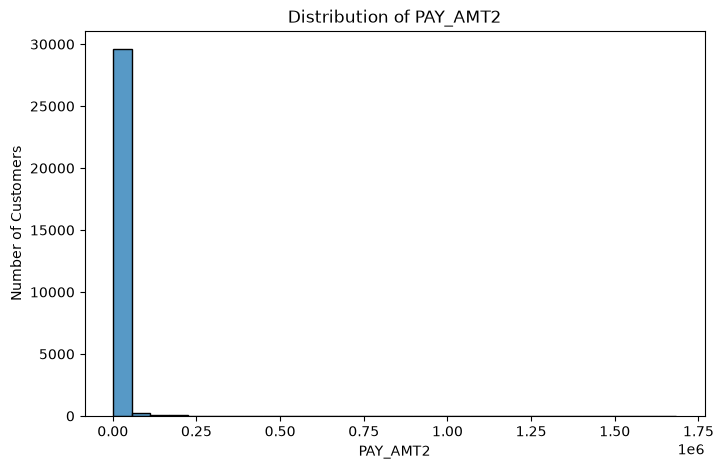

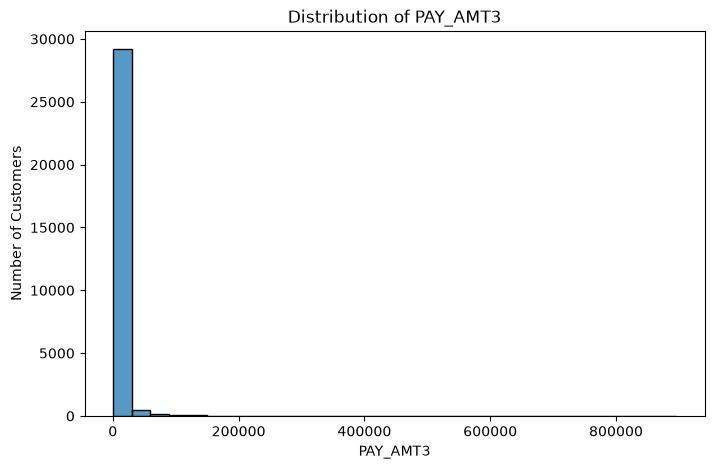

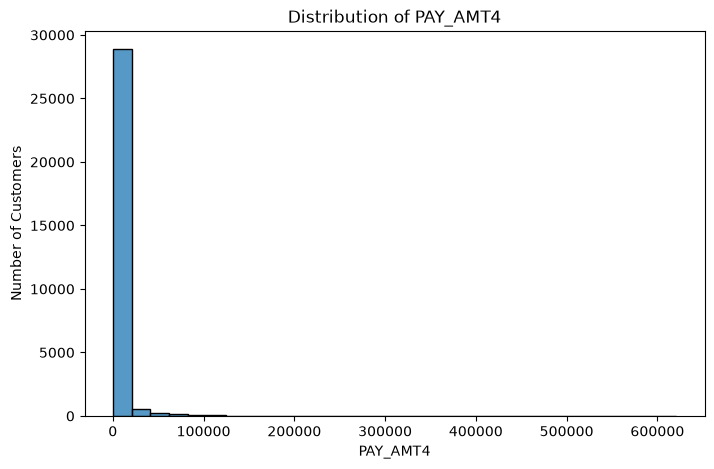

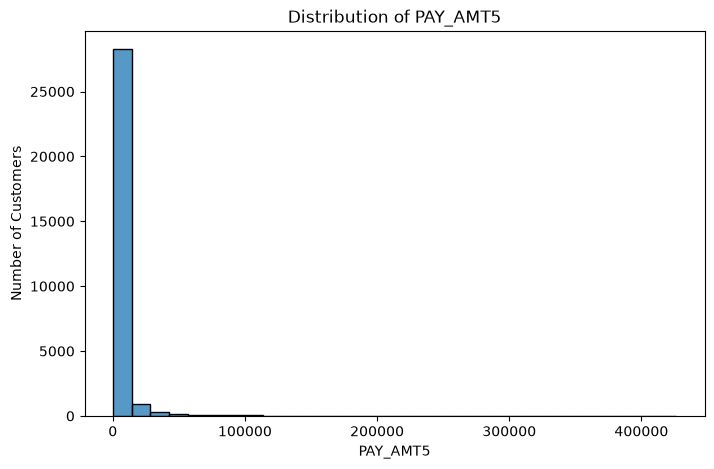

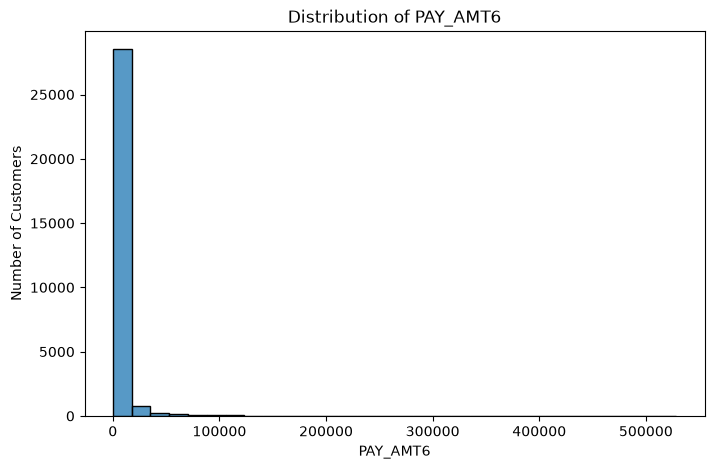

In [34]:
payment_cols = [
    "PAY_AMT1",
    "PAY_AMT2",
    "PAY_AMT3",
    "PAY_AMT4",
    "PAY_AMT5",
    "PAY_AMT6"
]

for col in payment_cols:
    plt.figure(figsize=(8, 5))
    sns.histplot(data=df, x=col, bins=30)
    plt.xlabel(col)
    plt.ylabel("Number of Customers")
    plt.title(f"Distribution of {col}")
    plt.show()


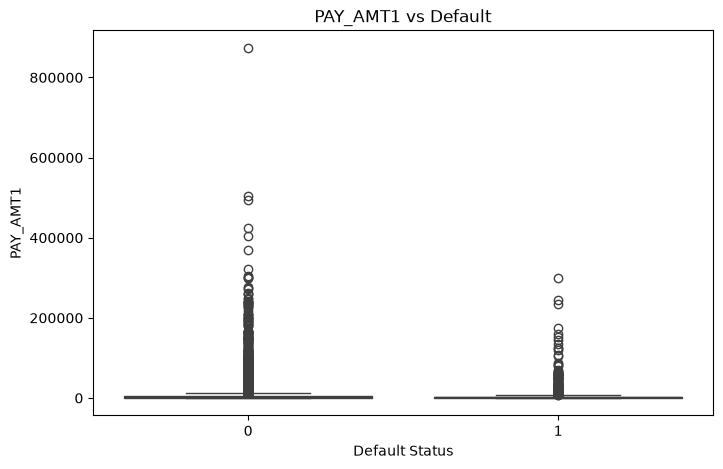

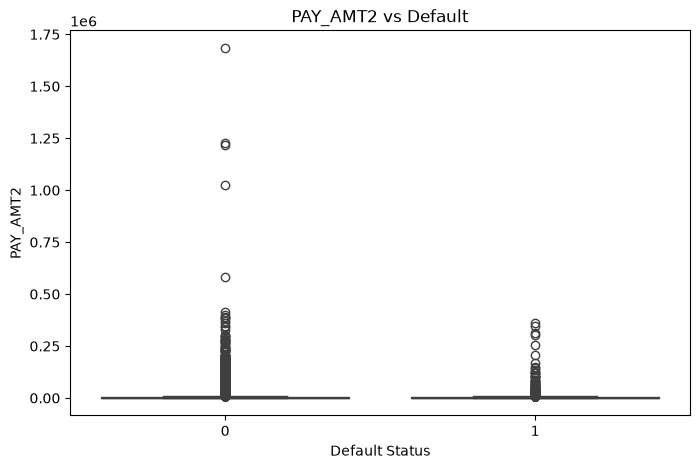

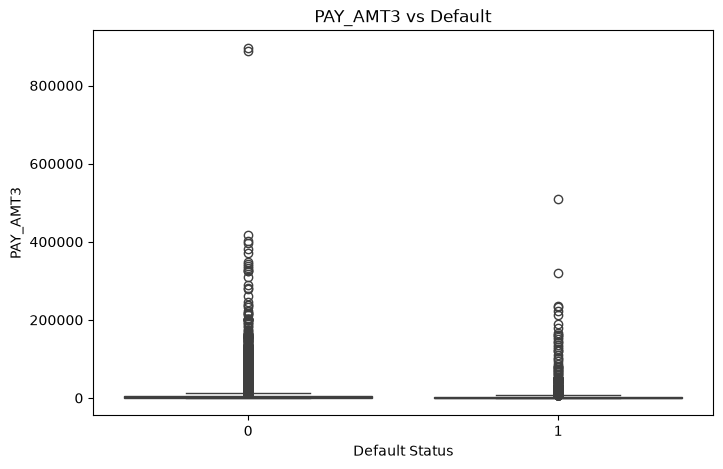

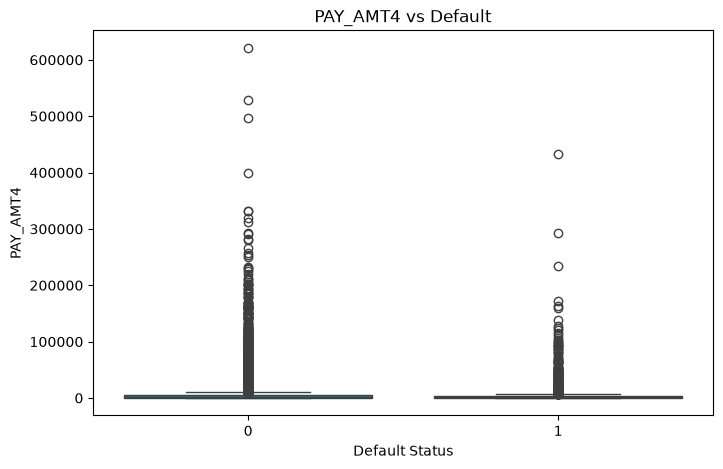

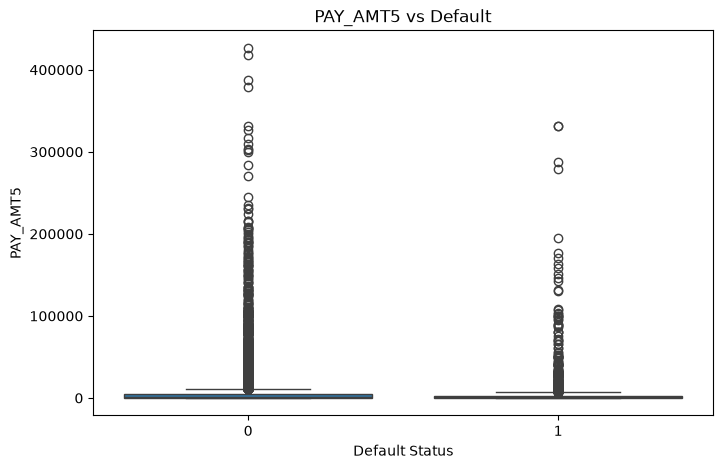

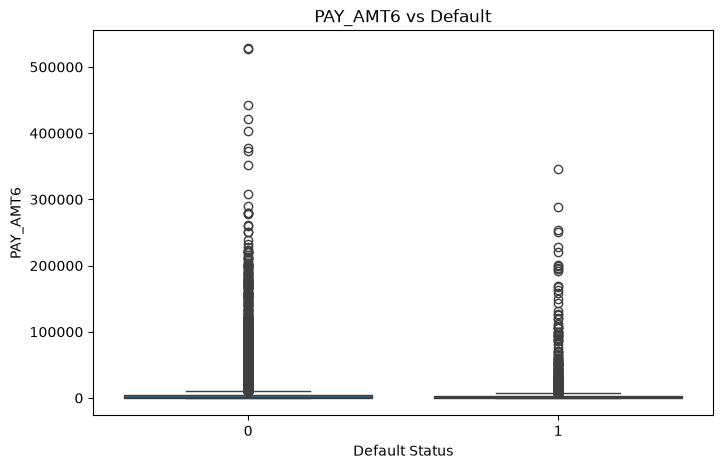

In [35]:
for col in payment_cols:
    plt.figure(figsize=(8, 5))
    sns.boxplot(data=df, x=target, y=col)
    plt.xlabel("Default Status")
    plt.ylabel(col)
    plt.title(f"{col} vs Default")
    plt.show()


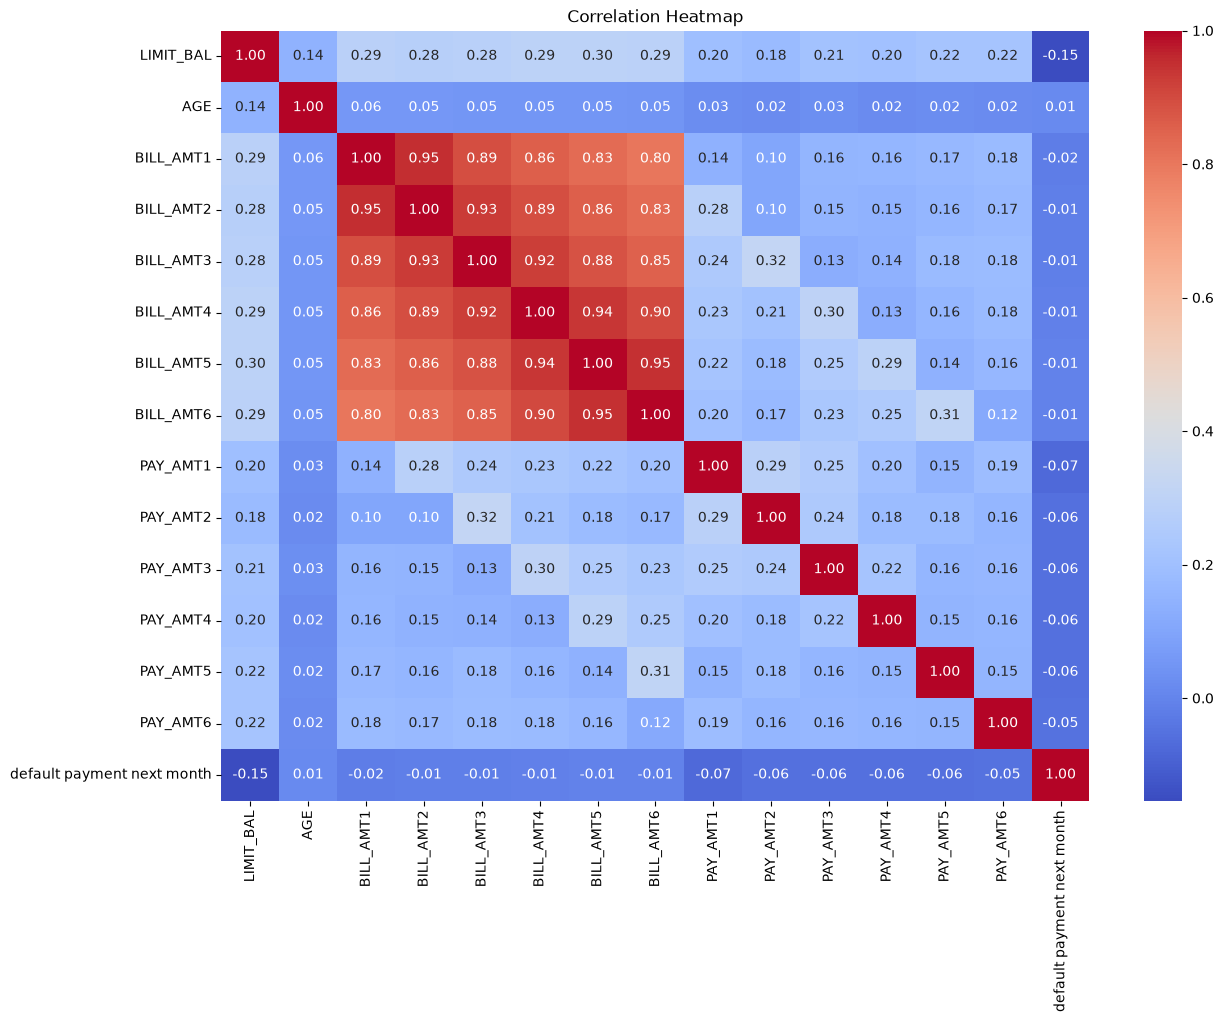

In [36]:
numeric_cols = [
    "LIMIT_BAL",
    "AGE",
    "BILL_AMT1",
    "BILL_AMT2",
    "BILL_AMT3",
    "BILL_AMT4",
    "BILL_AMT5",
    "BILL_AMT6",
    "PAY_AMT1",
    "PAY_AMT2",
    "PAY_AMT3",
    "PAY_AMT4",
    "PAY_AMT5",
    "PAY_AMT6",
    target
]

correlation = df[numeric_cols].corr()

plt.figure(figsize=(14, 10))
sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)
plt.title("Correlation Heatmap")
plt.show()


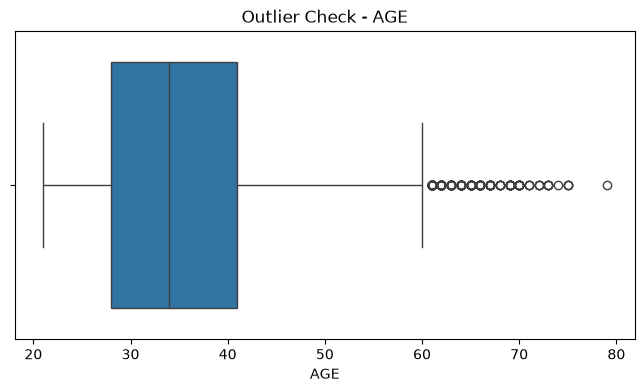

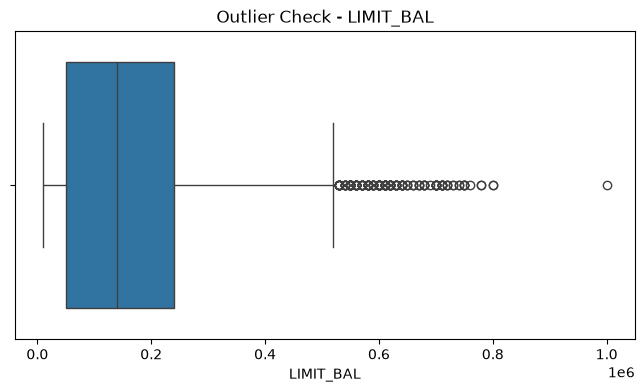

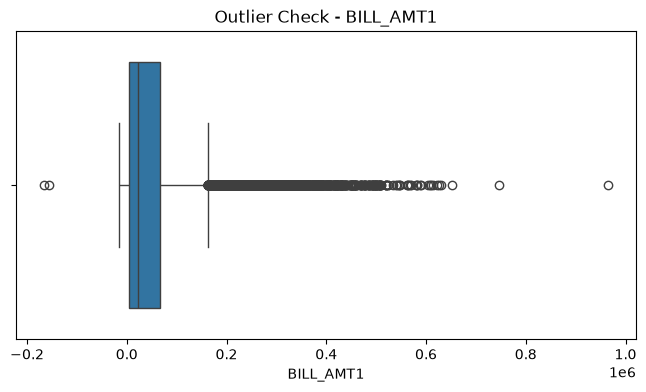

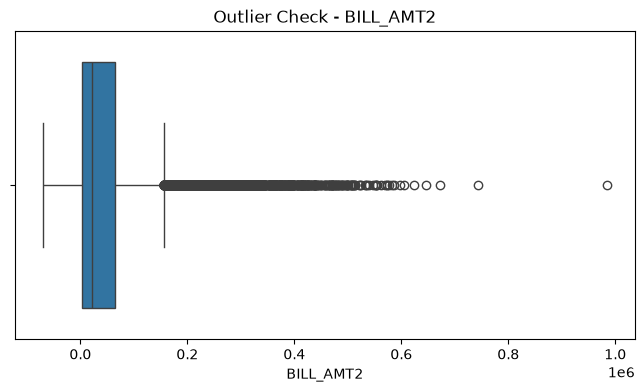

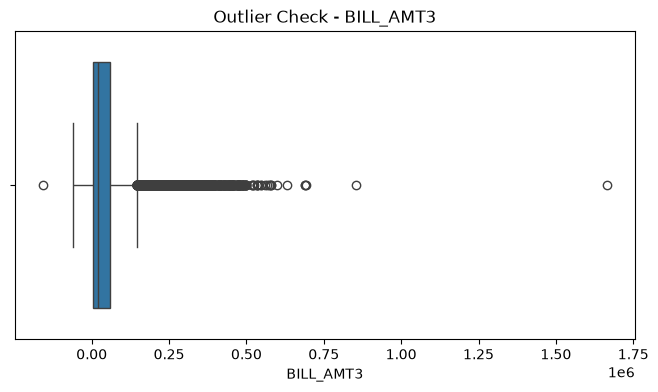

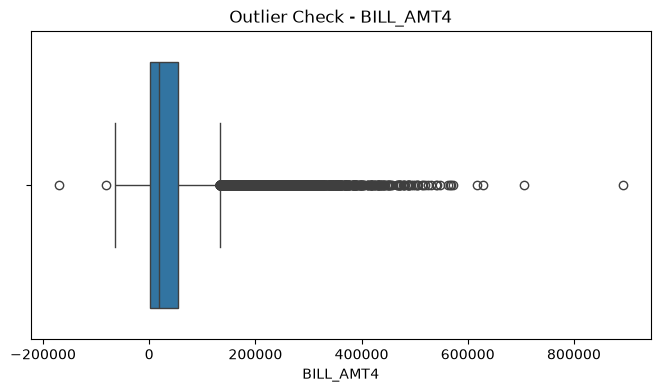

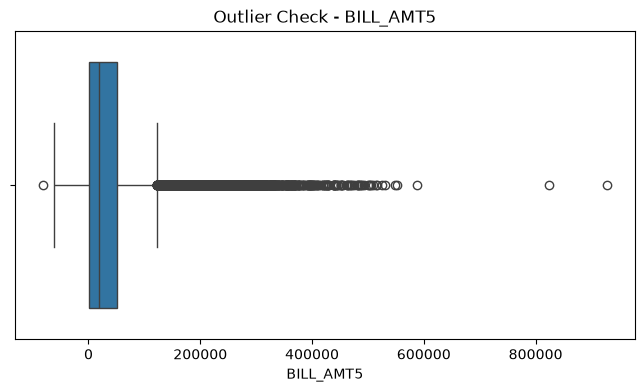

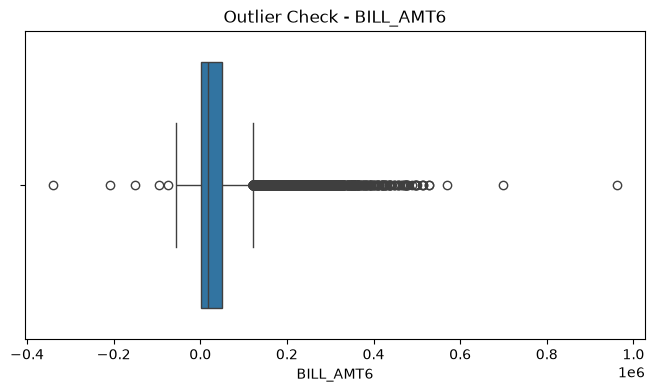

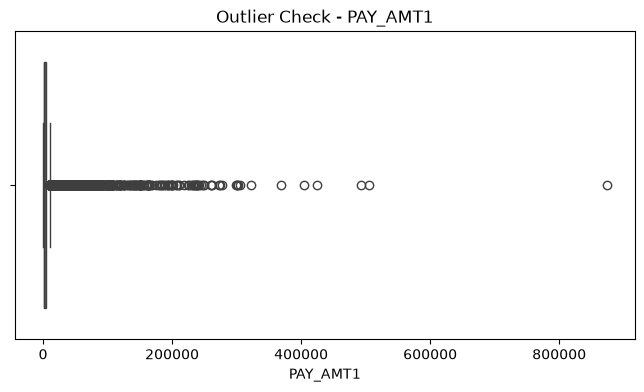

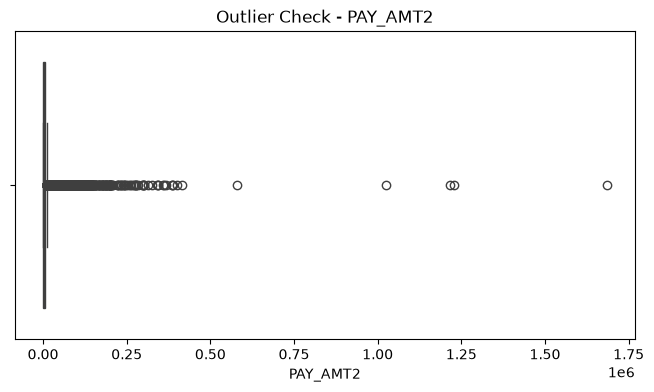

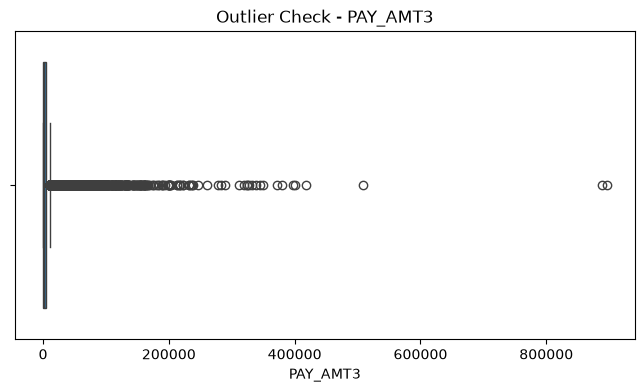

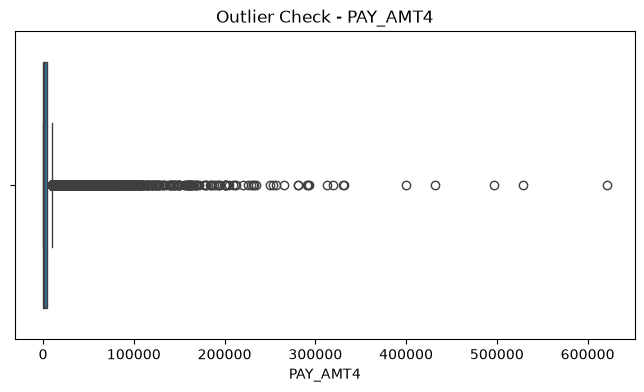

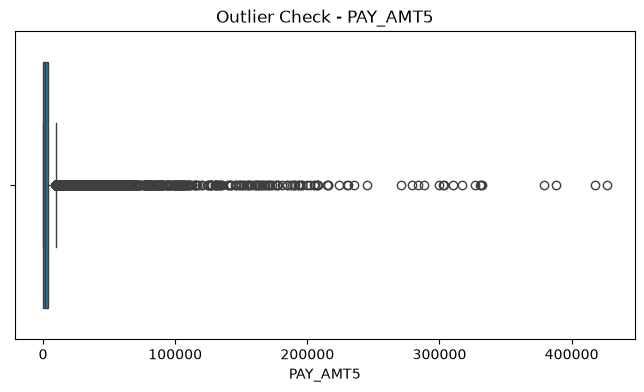

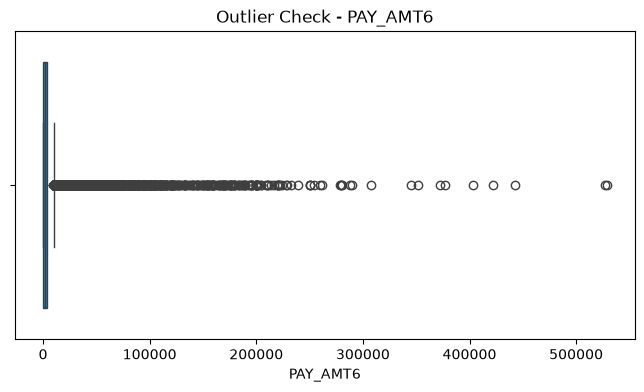

In [37]:
outlier_cols = [
    "AGE",
    "LIMIT_BAL",
    "BILL_AMT1",
    "BILL_AMT2",
    "BILL_AMT3",
    "BILL_AMT4",
    "BILL_AMT5",
    "BILL_AMT6",
    "PAY_AMT1",
    "PAY_AMT2",
    "PAY_AMT3",
    "PAY_AMT4",
    "PAY_AMT5",
    "PAY_AMT6"
]

for col in outlier_cols:
    plt.figure(figsize=(8, 4))
    sns.boxplot(x=df[col])
    plt.title(f"Outlier Check - {col}")
    plt.show()

In [38]:
import os

os.makedirs("../reports/figures", exist_ok=True)